In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.optimizer.ergodic_ilqr import ErgodicILQR
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 3
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.titlepad'] = 8.0
mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['lines.markersize'] = 5
mpl.rcParams['legend.fontsize'] = 15


In [2]:
from scipy.stats import multivariate_normal as mvn
mean1 = np.array([0.35, 0.38])
cov1 = np.array([[0.01, 0.004],[0.004, 0.01]])
w1 = 0.5

mean2 = np.array([0.68, 0.25])
cov2 = np.array([[0.005, -0.003],[-0.003, 0.005]])
w2 = 0.2

mean3 = np.array([0.56, 0.64])
cov3 = np.array([[0.008, 0.0],[0.0, 0.004]])
w3 = 0.3

def pdf(x):
    return (
        w1 * mvn.pdf(x, mean1, cov1) +
        w2 * mvn.pdf(x, mean2, cov2) +
        w3 * mvn.pdf(x, mean3, cov3)
    )

In [3]:
# domain
L_list = [10, 10]
grid_size = 50


# iLQR params
dt = 0.05
tsteps = 100

Q_z = np.eye(4) * 0.1
R_v = np.eye(2) * 0.1

# Q_z = np.diag([0.01, 0.01, 0.001, 0.001])
# R_v = np.diag([0.002, 0.001])

solver = ErgodicILQR(
    dt=dt,
    tsteps=tsteps,
    pdf=pdf,
    L_list=L_list,
    grid_size=grid_size,
    Q_z=Q_z,
    R_v=R_v,
    num_k= 10
)

In [4]:
x0 = np.array([1.0, 1.0, 0.0, 0.0])
u_init = np.zeros((tsteps, 2))

u_opt, cost_list, traj_list = solver.solve(x0, u_init, max_iter=100)

[CHECK] traj consistency: 0.000000e+00
[CHECK] ck mean: 1.0000e-02, std: 4.9990e-01
[CHECK] phik mean: 8.9701e-02
[CHECK] ||u|| = 0.0000
[CHECK] ||v|| = 939.9817
[CHECK] ck mean: 1.7321e-02, std: 1.1698e-01
[CHECK] phik mean: 8.9701e-02
[LS] alpha=1.00000, loss=88358.527261
[CHECK] ck mean: 2.1288e-02, std: 1.2500e-01
[CHECK] phik mean: 8.9701e-02
[LS] alpha=0.50000, loss=22091.276132
[CHECK] ck mean: 2.9281e-02, std: 1.4831e-01
[CHECK] phik mean: 8.9701e-02
[LS] alpha=0.25000, loss=5524.597533
[CHECK] ck mean: 4.7744e-02, std: 1.8265e-01
[CHECK] phik mean: 8.9701e-02
[LS] alpha=0.12500, loss=1384.085223
[CHECK] ck mean: 4.8576e-02, std: 2.0622e-01
[CHECK] phik mean: 8.9701e-02
[LS] alpha=0.06250, loss=349.603446
[CHECK] ck mean: 7.6560e-02, std: 2.3136e-01
[CHECK] phik mean: 8.9701e-02
[LS] alpha=0.03125, loss=91.607660
[CHECK] ck mean: 1.3223e-01, std: 2.7615e-01
[CHECK] phik mean: 8.9701e-02
[LS] alpha=0.01562, loss=29.153719
[CHECK] ck mean: 2.8722e-01, std: 3.2319e-01
[CHECK] phik

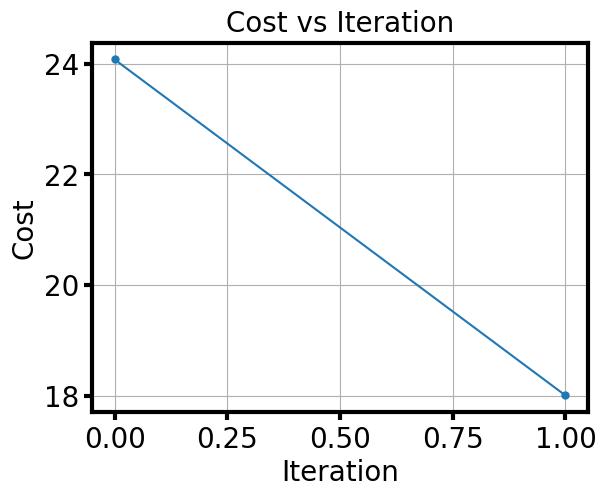

In [5]:
plt.figure()
plt.plot(cost_list, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration")
plt.grid()
plt.show()

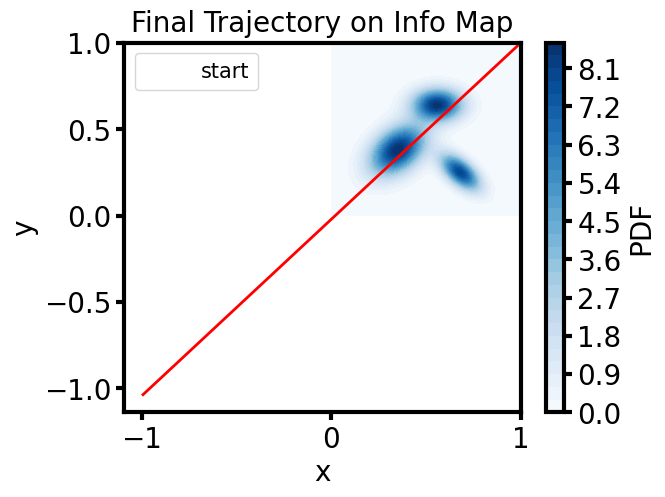

In [6]:
final_traj = traj_list[-1]


Nx, Ny = 100, 100
x = np.linspace(0, 1, Nx)
y = np.linspace(0, 1, Ny)
X, Y = np.meshgrid(x, y)
pts = np.stack([X.ravel(), Y.ravel()], axis=1)
Z = pdf(pts).reshape(Nx, Ny)

plt.contourf(X, Y, Z, levels=30, cmap="Blues")

plt.colorbar(label="PDF")

plt.plot(final_traj[:,0], final_traj[:,1], 'r-', linewidth=2)
plt.scatter(final_traj[0,0], final_traj[0,1], c='white', label='start')

plt.title("Final Trajectory on Info Map")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()